In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 3 datasets
features = pd.read_csv('data/Features data set.csv')
sales = pd.read_csv('data/sales data-set.csv')
stores = pd.read_csv('data/stores data-set.csv')

print("FEATURES SHAPE:", features.shape)
print("SALES SHAPE:", sales.shape)
print("STORES SHAPE:", stores.shape)

print("\nFEATURES COLUMNS:", features.columns.tolist())
print("SALES COLUMNS:", sales.columns.tolist())
print("STORES COLUMNS:", stores.columns.tolist())

FEATURES SHAPE: (8190, 12)
SALES SHAPE: (421570, 5)
STORES SHAPE: (45, 3)

FEATURES COLUMNS: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
SALES COLUMNS: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
STORES COLUMNS: ['Store', 'Type', 'Size']


In [5]:
# Cell 2 - Missing values and basic inspection
print("=== MISSING VALUES - FEATURES ===")
print(features.isnull().sum())

print("\n=== MISSING VALUES - SALES ===")
print(sales.isnull().sum())

print("\n=== MISSING VALUES - STORES ===")
print(stores.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Features duplicates:", features.duplicated().sum())
print("Sales duplicates:", sales.duplicated().sum())
print("Stores duplicates:", stores.duplicated().sum())

print("\n=== STORE TYPES ===")
print(stores['Type'].value_counts())

print("\n=== STORE SIZE STATS ===")
print(stores['Size'].describe())

=== MISSING VALUES - FEATURES ===
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

=== MISSING VALUES - SALES ===
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

=== MISSING VALUES - STORES ===
Store    0
Type     0
Size     0
dtype: int64

=== DUPLICATE ROWS ===
Features duplicates: 0
Sales duplicates: 0
Stores duplicates: 0

=== STORE TYPES ===
Type
A    22
B    17
C     6
Name: count, dtype: int64

=== STORE SIZE STATS ===
count        45.000000
mean     130287.600000
std       63825.271991
min       34875.000000
25%       70713.000000
50%      126512.000000
75%      202307.000000
max      219622.000000
Name: Size, dtype: float64


In [6]:
# Cell 3 - Data Cleaning (Fixed)
# Fix dates - dayfirst=True because format is DD/MM/YYYY
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)

# Fill MarkDown missing values with 0
# (no markdown = no promotion that week)
features['MarkDown1'] = features['MarkDown1'].fillna(0)
features['MarkDown2'] = features['MarkDown2'].fillna(0)
features['MarkDown3'] = features['MarkDown3'].fillna(0)
features['MarkDown4'] = features['MarkDown4'].fillna(0)
features['MarkDown5'] = features['MarkDown5'].fillna(0)

# Fill CPI and Unemployment with median
features['CPI'] = features['CPI'].fillna(features['CPI'].median())
features['Unemployment'] = features['Unemployment'].fillna(features['Unemployment'].median())

# Extract time features from sales
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['Month_Name'] = sales['Date'].dt.strftime('%b')
sales['Week'] = sales['Date'].dt.isocalendar().week
sales['Quarter'] = sales['Date'].dt.quarter
sales['Day_of_Week'] = sales['Date'].dt.day_name()
sales['Is_Weekend'] = sales['Date'].dt.dayofweek >= 5

# Merge all 3 files into one master dataframe
master = sales.merge(stores, on='Store', how='left')
master = master.merge(features, on=['Store', 'Date'], how='left')

print("✓ Dates fixed!")
print("✓ Missing values handled!")
print("✓ All 3 files merged into master dataframe!")
print("\nMASTER SHAPE:", master.shape)
print("\nDate Range:", sales['Date'].min(), "to", sales['Date'].max())
print("Total Stores:", sales['Store'].nunique())
print("Total Departments:", sales['Dept'].nunique())
print("Total Weekly Sales Records:", len(sales))

✓ Dates fixed!
✓ Missing values handled!
✓ All 3 files merged into master dataframe!

MASTER SHAPE: (421570, 24)

Date Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Total Stores: 45
Total Departments: 81
Total Weekly Sales Records: 421570


In [7]:
# Cell 4: Key Business Metrics and Analysis

# 1. Calculate Total Sales
total_sales = master["Weekly_Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

# 2. Calculate Average Weekly Sales
average_weekly_sales = master["Weekly_Sales"].mean()
print(f"Average Weekly Sales: ${average_weekly_sales:,.2f}")

# 3. Calculate Sales per Store
sales_per_store = master.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
print("\nSales per Store (Top 5):\n", sales_per_store.head())
print("\nSales per Store (Bottom 5):\n", sales_per_store.tail())

# 4. Calculate Sales per Department
sales_per_department = master.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)
print("\nSales per Department (Top 5):\n", sales_per_department.head())
print("\nSales per Department (Bottom 5):\n", sales_per_department.tail())

# 5. Calculate Sales per Store Type
sales_per_store_type = master.groupby("Type")["Weekly_Sales"].sum().sort_values(ascending=False)
print("\nSales per Store Type:\n", sales_per_store_type)

# 6. Calculate Sales per Store Size
sales_per_store_size = master.groupby("Size")["Weekly_Sales"].sum().sort_values(ascending=False)
print("\nSales per Store Size (Top 5):\n", sales_per_store_size.head())
print("\nSales per Store Size (Bottom 5):\n", sales_per_store_size.tail())


Total Sales: $6,737,218,987.11
Average Weekly Sales: $15,981.26

Sales per Store (Top 5):
 Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

Sales per Store (Bottom 5):
 Store
38    55159626.42
36    53412214.97
5     45475688.90
44    43293087.84
33    37160221.96
Name: Weekly_Sales, dtype: float64

Sales per Department (Top 5):
 Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
Name: Weekly_Sales, dtype: float64

Sales per Department (Bottom 5):
 Dept
51    30572.83
78     1714.71
39      177.98
43       14.32
47    -4962.93
Name: Weekly_Sales, dtype: float64

Sales per Store Type:
 Type
A    4.331015e+09
B    2.000701e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64

Sales per Store Size (Top 5):
 Size
203819    4.006509e+08
203742    3.013978e+08
205863    2.995440e+08
200898    2.889999e+08
219622    2.865177e+08
Name: Weekly_Sales, dtype

In [8]:
# Cell 4 - Key Business Metrics
print("=== KEY BUSINESS METRICS ===")
print("Total Revenue          : $", master['Weekly_Sales'].sum().round(2))
print("Average Weekly Sales   : $", master['Weekly_Sales'].mean().round(2))
print("Best Single Week Sales : $", master['Weekly_Sales'].max().round(2))
print("Total Stores           :", master['Store'].nunique())
print("Total Departments      :", master['Dept'].nunique())

print("\n=== SALES BY STORE TYPE ===")
print(master.groupby('Type')['Weekly_Sales'].sum().sort_values(ascending=False))

print("\n=== SALES BY YEAR ===")
print(master.groupby('Year')['Weekly_Sales'].sum())

print("\n=== SALES BY QUARTER ===")
print(master.groupby('Quarter')['Weekly_Sales'].sum())

print("\n=== HOLIDAY VS NON-HOLIDAY SALES ===")
print(master.groupby('IsHoliday_x')['Weekly_Sales'].mean().round(2))

print("\n=== TOP 10 STORES BY REVENUE ===")
print(master.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10))

print("\n=== TOP 10 DEPARTMENTS BY REVENUE ===")
print(master.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(10))

print("\n=== BOTTOM 5 STORES BY REVENUE ===")
print(master.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=True).head(5))

=== KEY BUSINESS METRICS ===
Total Revenue          : $ 6737218987.11
Average Weekly Sales   : $ 15981.26
Best Single Week Sales : $ 693099.36
Total Stores           : 45
Total Departments      : 81

=== SALES BY STORE TYPE ===
Type
A    4.331015e+09
B    2.000701e+09
C    4.055035e+08
Name: Weekly_Sales, dtype: float64

=== SALES BY YEAR ===
Year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

=== SALES BY QUARTER ===
Quarter
1    1.494112e+09
2    1.826615e+09
3    1.841852e+09
4    1.574639e+09
Name: Weekly_Sales, dtype: float64

=== HOLIDAY VS NON-HOLIDAY SALES ===
IsHoliday_x
False    15901.45
True     17035.82
Name: Weekly_Sales, dtype: float64

=== TOP 10 STORES BY REVENUE ===
Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

=== TOP 10 DEPARTMENTS B

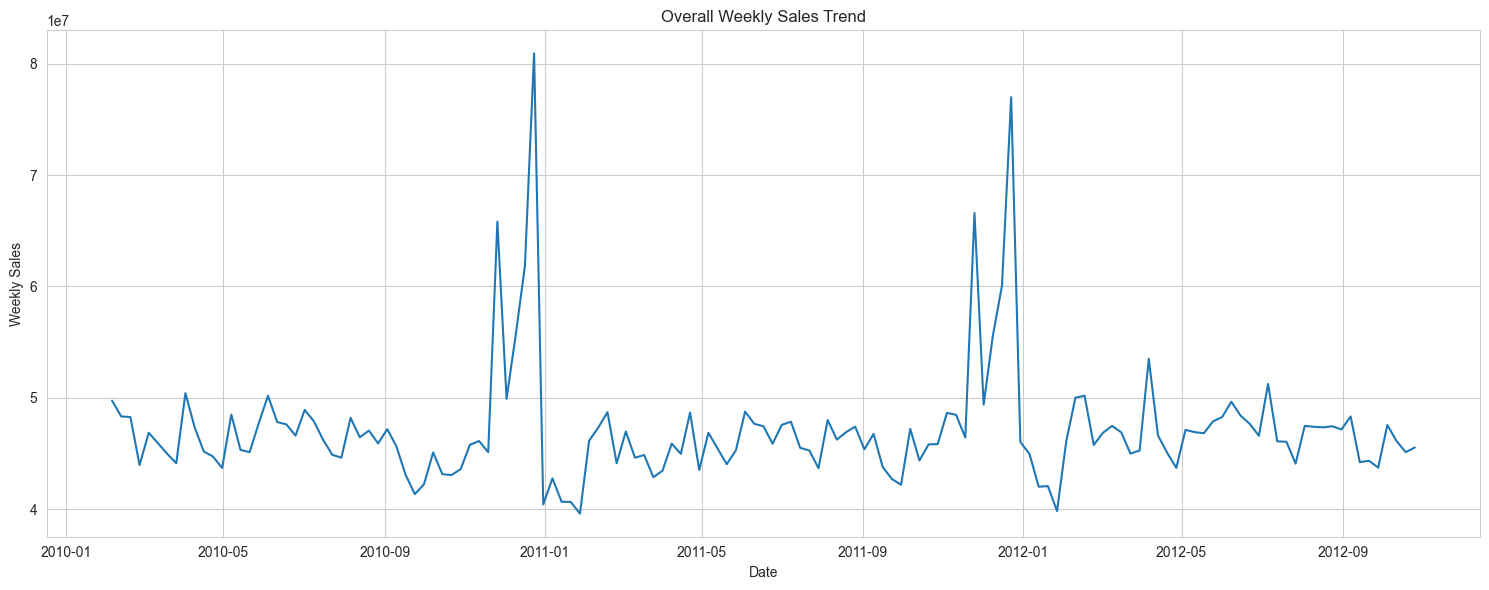

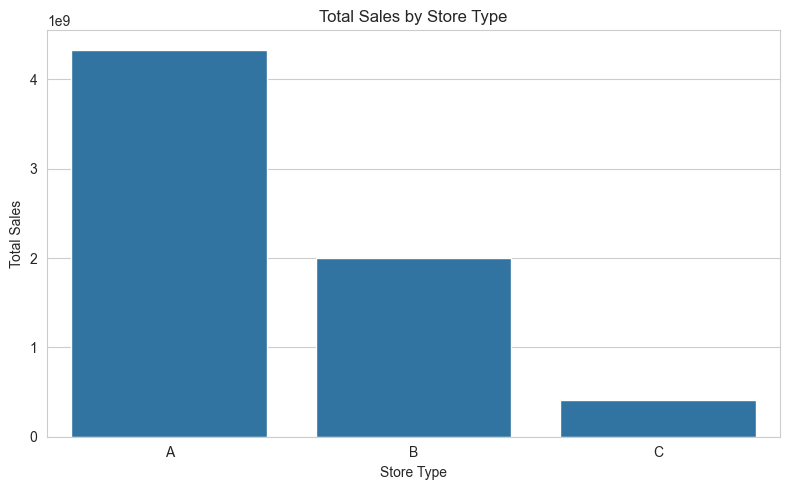

C:\Users\aswan\AppData\Local\Temp\ipykernel_17720\204648954.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Store", y="Weekly_Sales", data=sales_by_store, palette="viridis")


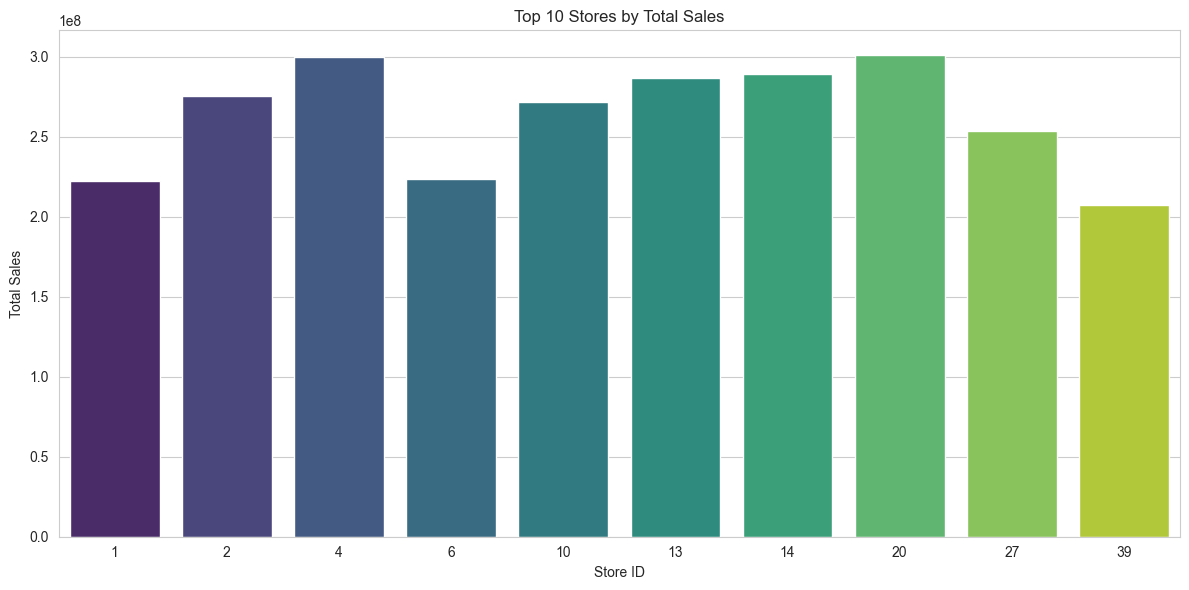

C:\Users\aswan\AppData\Local\Temp\ipykernel_17720\204648954.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Year", y="Weekly_Sales", data=sales_by_year, palette="magma")


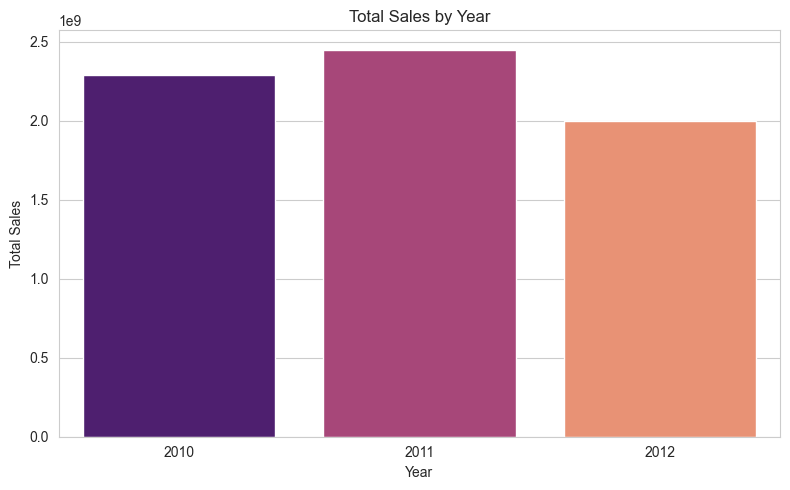

C:\Users\aswan\AppData\Local\Temp\ipykernel_17720\204648954.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="IsHoliday_x", y="Weekly_Sales", data=sales_holiday, palette="pastel")


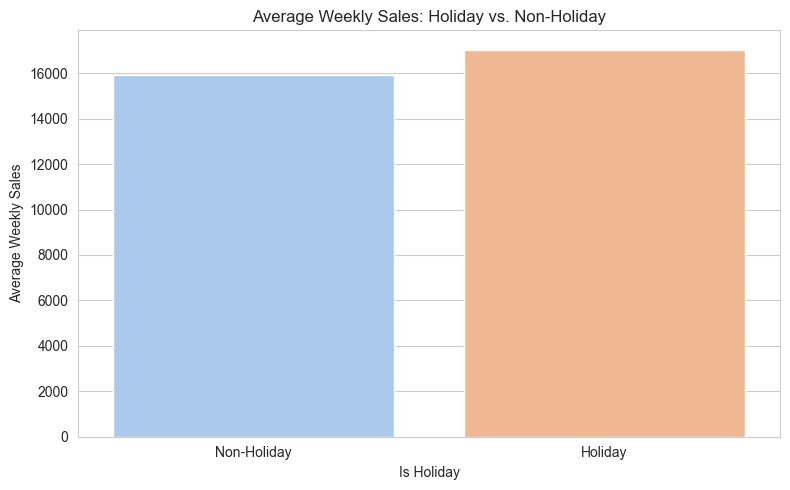

C:\Users\aswan\AppData\Local\Temp\ipykernel_17720\204648954.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Dept", y="Weekly_Sales", data=sales_by_dept, palette="cividis")


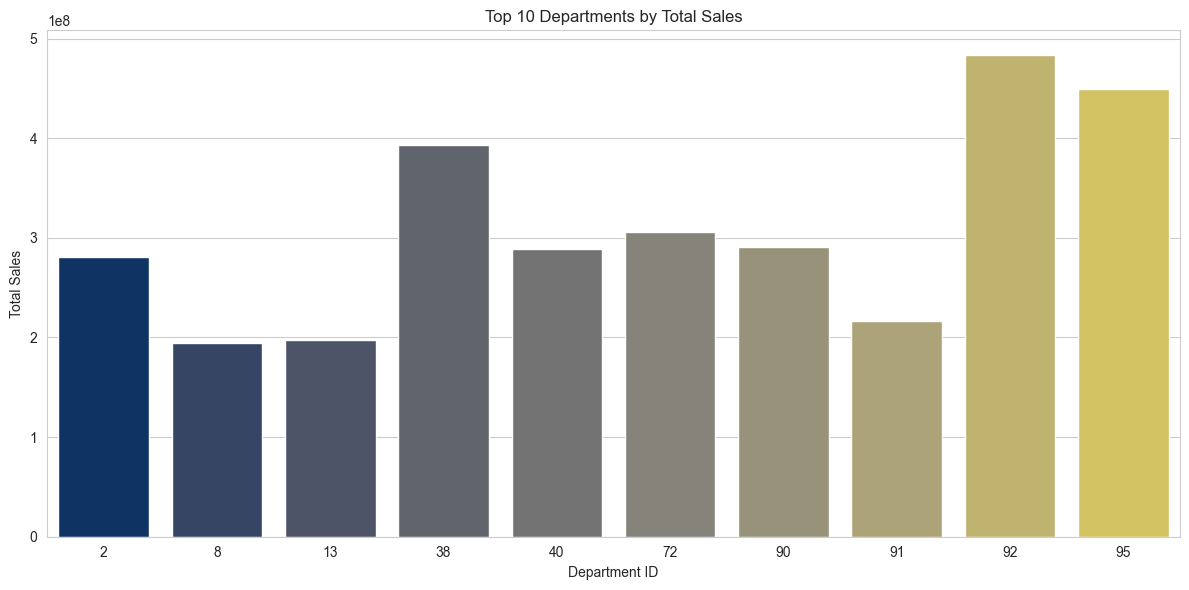

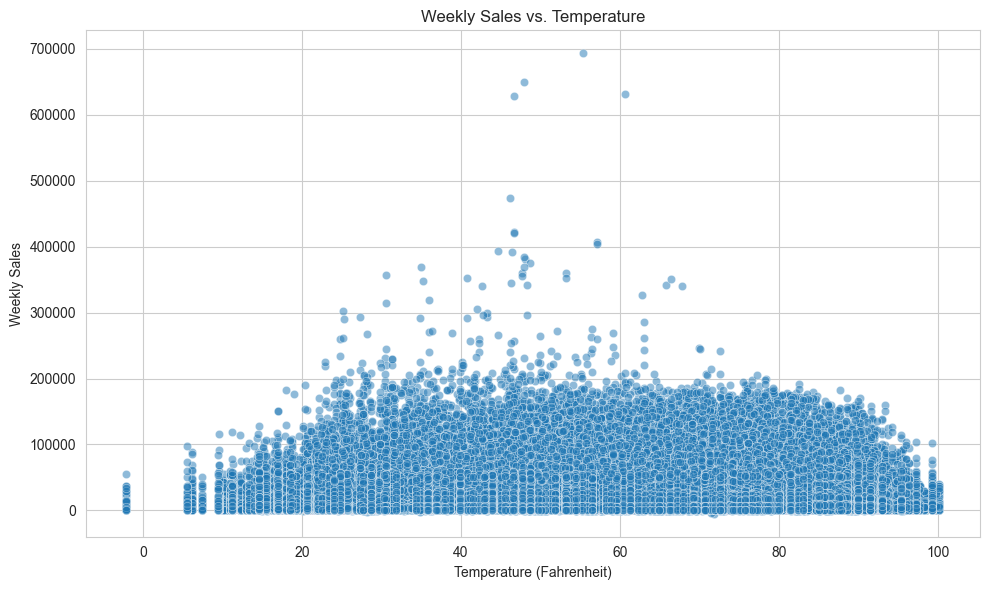

In [9]:
# Cell 5: Visualizations and Charts

# Ensure matplotlib and seaborn are imported
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# 1. Overall Weekly Sales Trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=master.groupby("Date")["Weekly_Sales"].sum().reset_index(), x="Date", y="Weekly_Sales")
plt.title("Overall Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

# 2. Sales by Store Type (Bar Chart)
plt.figure(figsize=(8, 5))
sales_by_type = master.groupby("Type")["Weekly_Sales"].sum().sort_values(ascending=False).reset_index()
sns.barplot(x="Type", y="Weekly_Sales", data=sales_by_type)
plt.title("Total Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# 3. Top 10 Stores by Sales (Bar Chart)
plt.figure(figsize=(12, 6))
sales_by_store = master.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="Store", y="Weekly_Sales", data=sales_by_store, palette="viridis")
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# 4. Sales by Year (Bar Chart)
plt.figure(figsize=(8, 5))
sales_by_year = master.groupby("Year")["Weekly_Sales"].sum().reset_index()
sns.barplot(x="Year", y="Weekly_Sales", data=sales_by_year, palette="magma")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# 5. Holiday vs. Non-Holiday Sales (Bar Chart)
plt.figure(figsize=(8, 5))
sales_holiday = master.groupby("IsHoliday_x")["Weekly_Sales"].mean().reset_index()
sns.barplot(x="IsHoliday_x", y="Weekly_Sales", data=sales_holiday, palette="pastel")
plt.title("Average Weekly Sales: Holiday vs. Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")
plt.xticks(ticks=[0, 1], labels=["Non-Holiday", "Holiday"])
plt.tight_layout()
plt.show()

# 6. Top 10 Departments by Sales (Bar Chart)
plt.figure(figsize=(12, 6))
sales_by_dept = master.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x="Dept", y="Weekly_Sales", data=sales_by_dept, palette="cividis")
plt.title("Top 10 Departments by Total Sales")
plt.xlabel("Department ID")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# 7. Weekly Sales vs. Temperature (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master, x="Temperature", y="Weekly_Sales", alpha=0.5)
plt.title("Weekly Sales vs. Temperature")
plt.xlabel("Temperature (Fahrenheit)")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()